# Falcon Challenge A — Programación resiliente de descargas

Notebook listo para Google Colab.

**Qué hace:**

1. Lee los CSV/JSON anexos del reto.
2. Convierte `Discharge.Best Available@08461300` de m³/s a volumen semanal.
3. Calcula el Storage Resilience Score (SRS).
4. Compara histórico, regla de umbral, regla balanceada, programación dinámica exacta y recocido simulado quantum-inspired.
5. Ejecuta escalamiento para T=12, T=26 y T=52.

Sube los archivos `DataSetExport-*.csv`, `falcon_reservoir_constants.json` y `falcon_download_manifest.json` al entorno de Colab antes de correr, o cambia `RUN_FILE_UPLOAD=True` en la primera celda.

In [ ]:
# ================================================================
# Falcon Challenge A - Programación resiliente de descargas
# Google Colab / Python 3
# ================================================================
# Este script resuelve el benchmark del International Falcon Reservoir:
#   - Lee series IBWC exportadas en CSV.
#   - Convierte Discharge.Best Available@08461300 de m3/s a volumen semanal m3.
#   - Construye la dinámica semanal del almacenamiento.
#   - Calcula SRS histórico, regla clásica de conservación y óptimo discreto.
#   - Resuelve exactamente el problema discreto con Programación Dinámica (DP).
#   - Incluye una sección opcional de recocido simulado quantum-inspired.
#   - Guarda resultados y gráficas.
# ================================================================

In [1]:
# =============================
# CELDA 1. Configuración Colab
# =============================
import os, glob, json, time, math, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

warnings.filterwarnings("ignore")
np.random.seed(42)

# Si estás en Google Colab y aún no has subido los CSV/JSON/PDF, cambia a True.
# Al ejecutar, selecciona los archivos del reto: DataSetExport-*.csv,
# falcon_reservoir_constants.json y falcon_download_manifest.json.
RUN_FILE_UPLOAD = True

if RUN_FILE_UPLOAD:
    try:
        from google.colab import files
        uploaded = files.upload()
    except Exception as e:
        print("Carga manual no disponible en este entorno:", e)

# En Colab normalmente los archivos subidos quedan en /content.
# En este chat están en /mnt/data. El script detecta ambos.
DATA_DIR_CANDIDATES = ["/content", "/mnt/data", "."]
DATA_DIR = next((d for d in DATA_DIR_CANDIDATES if os.path.exists(d)), ".")
print("DATA_DIR =", DATA_DIR)

Saving DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451.csv to DataSetExport-Discharge.Best Available@08461300-Instantaneous-m^3 s-20260629185451.csv
Saving DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344.csv to DataSetExport-Lake Area.Best Available@08461200-Instantaneous-m^2-20260629185344.csv
Saving DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142.csv to DataSetExport-Percentage.Conservation-Web-Telemetry@08461200-Instantaneous-%-20260630094142.csv
Saving DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508.csv to DataSetExport-Reservoir Elevation.Web-Daily-m@08461200-Instantaneous-m-20260629185508.csv
Saving DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416.csv to DataSetExport-Total Storage.Web-Daily-tcm@08461200-Instantaneous-m^3-20260629185416.csv
Saving falcon_download_manifest.json to falcon_download_ma

In [2]:
# =============================
# CELDA 2. Funciones de lectura y preparación de datos
# =============================
def find_file(pattern, data_dir=DATA_DIR):
    """Encuentra un archivo por patrón glob dentro del directorio de trabajo."""
    matches = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not matches:
        raise FileNotFoundError(
            f"No encontré archivos con patrón: {pattern}\n"
            f"Directorio actual: {data_dir}\n"
            "Sube los CSV/JSON del reto o ajusta DATA_DIR."
        )
    return matches[0]


def read_ibwc_csv(path, value_name="value"):
    """
    Lee CSV exportado de IBWC.
    Los archivos tienen una primera línea con '#Data Set Export...' y una nota legal al final.
    Esta función conserva únicamente filas con timestamp válido.
    """
    df = pd.read_csv(path, comment="#")
    df.columns = [c.strip() for c in df.columns]
    time_col, value_col = df.columns[0], df.columns[1]

    mask_dates = df[time_col].astype(str).str.match(r"^\d{4}-\d{2}-\d{2}", na=False)
    df = df.loc[mask_dates].copy()
    df["timestamp"] = pd.to_datetime(df[time_col], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["timestamp", value_name]).sort_values("timestamp")
    df = df[["timestamp", value_name]].set_index("timestamp")
    return df


def integrate_discharge_to_weekly_volume(flow_df, freq="W-SUN"):
    """
    Convierte caudal m3/s a volumen semanal m3.
    Usa integración tipo rectángulo izquierdo: volumen = q(t) * duración_hasta_siguiente_medición.
    Para huecos grandes usa el intervalo mediano para evitar inflar artificialmente el volumen.
    """
    df = flow_df.copy().sort_index()
    q_col = df.columns[0]
    idx = df.index

    median_dt = idx.to_series().diff().median()
    if pd.isna(median_dt) or median_dt <= pd.Timedelta(0):
        median_dt = pd.Timedelta(minutes=15)

    next_idx = idx.to_series().shift(-1)
    duration_s = (next_idx - idx.to_series()).dt.total_seconds().to_numpy()
    duration_s[-1] = median_dt.total_seconds()

    med_s = median_dt.total_seconds()
    duration_s = np.where((duration_s <= 0) | (duration_s > 3 * med_s), med_s, duration_s)

    df["volume_m3"] = df[q_col].to_numpy(dtype=float) * duration_s

    # Semanas de domingo 00:00 a domingo 00:00, consistente con los datos entregados.
    weekly = df["volume_m3"].resample(freq, label="left", closed="left").sum().to_frame("Robs_m3")
    counts = df["volume_m3"].resample(freq, label="left", closed="left").count()

    # Retener semanas razonablemente completas: 7 días * 24 horas * 4 mediciones/hora * 80%.
    weekly = weekly.loc[counts >= 7 * 24 * 4 * 0.80]
    return weekly


def weekly_storage_boundaries(storage_df):
    """
    Toma almacenamiento observado en domingos 00:00 como fronteras semanales.
    Para T decisiones semanales se necesitan T+1 fronteras de almacenamiento.
    """
    s_col = storage_df.columns[0]
    sunday = storage_df.loc[storage_df.index.dayofweek == 6].copy()
    sunday = sunday.rename(columns={s_col: "Sobs_m3"})
    return sunday


def levels_for_L(L):
    """Niveles simétricos enteros para L impar. L=5 -> [-2,-1,0,1,2]."""
    if L % 2 != 1:
        raise ValueError("Este script asume L impar: 3, 5, 7, ...")
    return np.arange(-(L // 2), L // 2 + 1, dtype=int)


@dataclass
class FalconParams:
    T: int = 26
    L: int = 5
    eta: float = 0.10
    smax_m3: float = 3288726000.0
    smin_m3: float = 822181500.0


def load_constants():
    """Carga Smax desde falcon_reservoir_constants.json si está disponible."""
    try:
        const_path = find_file("falcon_reservoir_constants.json")
        with open(const_path, "r", encoding="utf-8") as f:
            const = json.load(f)
        smax = float(const["s_max_m3"])
    except Exception:
        # Valor del archivo anexo: 3288.726 MCM = 3,288,726,000 m3.
        smax = 3288726000.0
    return smax, 0.25 * smax


def prepare_weekly_instance(T=26, L=5, start_date=None):
    """
    Prepara el caso semanal:
      Robs[t] = descarga observada semanal en m3.
      Sobs[t] = almacenamiento observado al inicio de cada semana en m3.
    Si no se proporciona start_date, usa la primera semana completa disponible.
    """
    discharge_path = find_file("DataSetExport-Discharge.Best Available@08461300*.csv")
    storage_path = find_file("DataSetExport-Total Storage.Web-Daily*.csv")

    flow = read_ibwc_csv(discharge_path, "q_m3s")
    storage = read_ibwc_csv(storage_path, "storage_m3")

    weekly_R = integrate_discharge_to_weekly_volume(flow)
    weekly_S = weekly_storage_boundaries(storage)

    # Elegir fecha de arranque en semanas con release y frontera de almacenamiento.
    common_starts = weekly_R.index.intersection(weekly_S.index).sort_values()
    if len(common_starts) == 0:
        raise ValueError("No hay semanas comunes entre descarga y almacenamiento.")

    if start_date is None:
        start = common_starts[0]
    else:
        start_date = pd.to_datetime(start_date)
        eligible = common_starts[common_starts >= start_date]
        if len(eligible) == 0:
            raise ValueError("start_date queda fuera del rango de datos.")
        start = eligible[0]

    starts = weekly_R.loc[start:].index[:T]
    s_boundaries = weekly_S.loc[start:].index[: T + 1]
    if len(starts) < T:
        raise ValueError(f"No hay suficientes semanas de descarga para T={T}.")
    if len(s_boundaries) < T + 1:
        raise ValueError(f"No hay suficientes fronteras de almacenamiento para T={T}.")

    Robs = weekly_R.loc[starts, "Robs_m3"].to_numpy(dtype=float)
    Sobs = weekly_S.loc[s_boundaries, "Sobs_m3"].to_numpy(dtype=float)

    smax, smin = load_constants()
    params = FalconParams(T=T, L=L, eta=0.10, smax_m3=smax, smin_m3=smin)
    dates = pd.Index(s_boundaries)
    return Robs, Sobs, dates, params

In [3]:
# =============================
# CELDA 3. SRS, restricciones y políticas base
# =============================
def official_weights(T, smin, umax):
    """Pesos oficiales del benchmark."""
    w1 = 1.0 / ((T + 1) * smin**2)
    w2 = 0.1 / (T * umax**2) if umax > 0 else 0.0
    w3 = 0.1 / ((T - 1) * (2 * umax) ** 2) if T > 1 and umax > 0 else 0.0
    return w1, w2, w3


def compute_storage_path(Sobs, u):
    """
    Sopt(t) = Sobs(t) - sum_{i=0}^{t-1} u(i).
    Equivale a Sopt(t+1) = Sopt(t) + ΔSobs(t) - u(t).
    """
    u = np.asarray(u, dtype=float)
    cumulative_u = np.concatenate([[0.0], np.cumsum(u)])
    return np.asarray(Sobs, dtype=float) - cumulative_u


def evaluate_policy(u, Robs, Sobs, smin, smax, eta, weights):
    """Calcula SRS, componentes de costo, trayectorias y factibilidad."""
    u = np.asarray(u, dtype=float)
    Robs = np.asarray(Robs, dtype=float)
    T = len(u)

    Sopt = compute_storage_path(Sobs, u)
    R = Robs + u
    w1, w2, w3 = weights

    Ccrit = np.sum(np.maximum(0.0, smin - Sopt) ** 2)
    Cdev = np.sum(u**2)
    Csmooth = np.sum(np.diff(u) ** 2) if T > 1 else 0.0
    cost = w1 * Ccrit + w2 * Cdev + w3 * Csmooth
    SRS = -cost

    feasible = {
        "release_nonnegative": bool(np.all(R >= -1e-8)),
        "storage_bounds": bool(np.all((Sopt >= -1e-8) & (Sopt <= smax + 1e-8))),
        "balance": bool(abs(u.sum()) <= eta * Robs.sum() + 1e-8),
    }
    feasible["all"] = all(feasible.values())

    return {
        "SRS": SRS,
        "cost": cost,
        "Ccrit": Ccrit,
        "Cdev": Cdev,
        "Csmooth": Csmooth,
        "Sopt": Sopt,
        "R": R,
        "u": u,
        "feasible": feasible,
        "sum_u": float(u.sum()),
        "min_storage_pct_cap": float(np.min(Sopt / smax * 100.0)),
        "min_release_m3": float(np.min(R)),
    }


def historical_policy(T):
    """u(t)=0: reproducción histórica."""
    return np.zeros(T, dtype=float)


def threshold_rule(Robs, Sobs, delta_u, smin, smax, eta, enforce_balance=False):
    """
    Regla clásica: u(t)=-Δu si Srule(t)<Smin, en otro caso 0.
    enforce_balance=False reproduce literalmente la regla del reto.
    enforce_balance=True detiene reducciones cuando excedería el balance acumulado.
    """
    T = len(Robs)
    u = []
    Scur = float(Sobs[0])
    balance_budget = eta * np.sum(Robs)
    used = 0.0

    for t in range(T):
        cand = -delta_u if Scur < smin else 0.0
        if enforce_balance and abs(used + cand) > balance_budget:
            cand = 0.0

        # Ajustes mínimos para no generar descarga negativa ni almacenamiento fuera de rango.
        if Robs[t] + cand < 0:
            cand = -Robs[t]
        nextS = Scur + (Sobs[t + 1] - Sobs[t]) - cand
        if nextS > smax:
            cand = Scur + (Sobs[t + 1] - Sobs[t]) - smax
        if nextS < 0:
            cand = Scur + (Sobs[t + 1] - Sobs[t])

        u.append(cand)
        used += cand
        Scur = Scur + (Sobs[t + 1] - Sobs[t]) - cand

    return np.asarray(u, dtype=float)

In [5]:
# =============================
# CELDA 4. Programación Dinámica exacta
# =============================
def dp_optimize(Robs, Sobs, L, smin, smax, eta, delta_u=None):
    """
    Optimización exacta para niveles discretos.

    Estado DP:
      t = semana actual
      cum_units = suma acumulada de niveles enteros k, donde u=k*Δu
      prev_idx = nivel anterior para calcular suavidad

    Como Sopt(t) depende solo de la suma acumulada de u, no es necesario enumerar L^T.
    """
    T = len(Robs)
    unit_levels = levels_for_L(L)
    if delta_u is None:
        delta_u = 0.25 * np.median(Robs)
    u_values = unit_levels * delta_u
    umax = float(np.max(np.abs(u_values)))
    weights = official_weights(T, smin, umax)
    w1, w2, w3 = weights

    S0 = float(Sobs[0])
    if not (0 <= S0 <= smax):
        raise ValueError(f"S0 fuera de límites: {S0:,.0f} m3")

    initial_cost = w1 * max(0.0, smin - S0) ** 2
    states = {(0, None): (initial_cost, [])}  # (cum_units, prev_idx) -> (cost, path_units)

    min_unit = int(unit_levels.min())
    max_unit = int(unit_levels.max())
    balance_units = int(np.floor(eta * np.sum(Robs) / delta_u + 1e-12))

    for t in range(T):
        new_states = {}
        remaining = T - t - 1
        for (cum_units, prev_idx), (cost, path) in states.items():
            for i, k in enumerate(unit_levels):
                u_t = float(u_values[i])

                # R(t) >= 0
                if Robs[t] + u_t < -1e-8:
                    continue

                new_cum = int(cum_units + k)

                # Poda: ¿aún es posible cumplir el balance al final?
                min_possible = new_cum + remaining * min_unit
                max_possible = new_cum + remaining * max_unit
                if min_possible > balance_units or max_possible < -balance_units:
                    continue

                # Sopt(t+1) = Sobs(t+1) - Δu * suma_unidades
                S_after = float(Sobs[t + 1] - delta_u * new_cum)
                if S_after < -1e-8 or S_after > smax + 1e-8:
                    continue

                inc = w1 * max(0.0, smin - S_after) ** 2 + w2 * u_t**2
                if prev_idx is not None:
                    inc += w3 * (u_t - float(u_values[prev_idx])) ** 2

                new_cost = cost + inc
                key = (new_cum, i)
                if key not in new_states or new_cost < new_states[key][0]:
                    new_states[key] = (new_cost, path + [int(k)])

        states = new_states
        if not states:
            raise RuntimeError(f"No hay estados factibles en t={t}.")

    best = None
    for (cum_units, prev_idx), (cost, path) in states.items():
        if abs(cum_units * delta_u) <= eta * np.sum(Robs) + 1e-8:
            if best is None or cost < best[0]:
                best = (cost, path)

    if best is None:
        raise RuntimeError("No se encontró política factible que cumpla balance acumulado.")

    best_cost, path_units = best
    u_opt = np.asarray(path_units, dtype=float) * delta_u
    meta = {
        "delta_u": float(delta_u),
        "umax": umax,
        "weights": weights,
        "unit_levels": unit_levels,
        "states_final": len(states),
        "best_cost": float(best_cost),
    }
    return u_opt, meta

In [6]:
# =============================
# CELDA 5. Recocido simulado quantum-inspired opcional
# =============================
def simulated_annealing_optimize(
    Robs,
    Sobs,
    L,
    smin,
    smax,
    eta,
    delta_u,
    weights,
    n_iter=30000,
    T0=0.02,
    Tmin=1e-7,
    seed=42,
):
    """
    Heurística tipo annealing, útil como comparación quantum-inspired.
    No garantiza óptimo global; DP se usa como solución exacta para el benchmark discreto.
    """
    rng = np.random.default_rng(seed)
    T = len(Robs)
    unit_levels = levels_for_L(L)

    def objective(units):
        u = np.asarray(units, dtype=float) * delta_u
        ev = evaluate_policy(u, Robs, Sobs, smin, smax, eta, weights)
        # Penalizaciones normalizadas por violar restricciones.
        R = ev["R"]
        S = ev["Sopt"]
        rel_pen = np.maximum(0, -R).sum() / max(np.sum(Robs), 1.0)
        stor_pen = (np.maximum(0, -S).sum() + np.maximum(0, S - smax).sum()) / max(smax, 1.0)
        bal_pen = max(0.0, abs(u.sum()) - eta * np.sum(Robs)) / max(np.sum(Robs), 1.0)
        return ev["cost"] + 1000.0 * (rel_pen + stor_pen + bal_pen), ev

    current = np.zeros(T, dtype=int)
    current_score, current_ev = objective(current)
    best = current.copy()
    best_score, best_ev = current_score, current_ev

    for it in range(n_iter):
        temp = T0 * (Tmin / T0) ** (it / max(n_iter - 1, 1))
        candidate = current.copy()
        pos = rng.integers(T)
        candidate[pos] = rng.choice(unit_levels)
        cand_score, cand_ev = objective(candidate)

        accept = cand_score < current_score
        if not accept:
            accept = rng.random() < math.exp((current_score - cand_score) / max(temp, 1e-12))

        if accept:
            current, current_score, current_ev = candidate, cand_score, cand_ev
            if current_ev["feasible"]["all"] and current_score < best_score:
                best, best_score, best_ev = current.copy(), current_score, current_ev

    return best.astype(float) * delta_u, {"score": best_score, "eval": best_ev}

In [7]:
# =============================
# CELDA 6. Ejecutar caso oficial: T=26, L=5
# =============================
T_OFFICIAL = 26
L_OFFICIAL = 5
START_DATE = None  # ejemplo: "2025-06-29". None = primera semana completa disponible.

Robs, Sobs, dates, params = prepare_weekly_instance(T=T_OFFICIAL, L=L_OFFICIAL, start_date=START_DATE)

delta_u = 0.25 * np.median(Robs)
unit_levels = levels_for_L(L_OFFICIAL)
umax = np.max(np.abs(unit_levels * delta_u))
weights = official_weights(T_OFFICIAL, params.smin_m3, umax)

print(f"Ventana: {dates[0].date()} a {dates[-1].date()} | T={T_OFFICIAL}, L={L_OFFICIAL}")
print(f"Smax = {params.smax_m3/1e6:,.3f} Mm3 | Smin = {params.smin_m3/1e6:,.3f} Mm3")
print(f"Mediana semanal Robs = {np.median(Robs)/1e6:,.3f} Mm3 | Δu = {delta_u/1e6:,.3f} Mm3")
print(f"Niveles u/Δu = {unit_levels.tolist()} | umax = {umax/1e6:,.3f} Mm3")

# Políticas base.
u_hist = historical_policy(T_OFFICIAL)
u_rule = threshold_rule(Robs, Sobs, delta_u, params.smin_m3, params.smax_m3, params.eta, enforce_balance=False)
u_rule_bal = threshold_rule(Robs, Sobs, delta_u, params.smin_m3, params.smax_m3, params.eta, enforce_balance=True)

# Optimización exacta DP.
t0 = time.perf_counter()
u_dp, dp_meta = dp_optimize(Robs, Sobs, L_OFFICIAL, params.smin_m3, params.smax_m3, params.eta, delta_u)
runtime_dp = time.perf_counter() - t0

# Recocido simulado opcional. Cambia a True si quieres correrlo.
RUN_ANNEALING = True
if RUN_ANNEALING:
    t0 = time.perf_counter()
    u_sa, sa_meta = simulated_annealing_optimize(
        Robs, Sobs, L_OFFICIAL, params.smin_m3, params.smax_m3,
        params.eta, delta_u, dp_meta["weights"], n_iter=30000
    )
    runtime_sa = time.perf_counter() - t0
else:
    u_sa, sa_meta, runtime_sa = None, None, None

# Evaluaciones.
policies = {
    "Histórico u=0": (u_hist, 0.0),
    "Regla umbral": (u_rule, 0.0),
    "Regla umbral balanceada": (u_rule_bal, 0.0),
    "Óptimo DP exacto": (u_dp, runtime_dp),
}
if RUN_ANNEALING:
    policies["Annealing quantum-inspired"] = (u_sa, runtime_sa)

rows = []
evals = {}
for name, (u, rt) in policies.items():
    ev = evaluate_policy(u, Robs, Sobs, params.smin_m3, params.smax_m3, params.eta, dp_meta["weights"])
    evals[name] = ev
    rows.append({
        "política": name,
        "SRS": ev["SRS"],
        "factible": ev["feasible"]["all"],
        "R>=0": ev["feasible"]["release_nonnegative"],
        "0<=S<=Smax": ev["feasible"]["storage_bounds"],
        "balance": ev["feasible"]["balance"],
        "sum_u_Mm3": ev["sum_u"] / 1e6,
        "min_S_%cap": ev["min_storage_pct_cap"],
        "min_R_Mm3": ev["min_release_m3"] / 1e6,
        "runtime_s": rt,
    })

summary = pd.DataFrame(rows).sort_values("SRS", ascending=False).reset_index(drop=True)
summary["ΔSRS_vs_hist"] = summary["SRS"] - evals["Histórico u=0"]["SRS"]
summary["ΔSRS_vs_regla_balanceada"] = summary["SRS"] - evals["Regla umbral balanceada"]["SRS"]

pd.set_option("display.precision", 6)
display(summary)

print("\nMejor política factible:")
feasible_summary = summary[summary["factible"] == True]
display(feasible_summary.head(1))

Ventana: 2025-06-29 a 2025-12-28 | T=26, L=5
Smax = 3,288.726 Mm3 | Smin = 822.182 Mm3
Mediana semanal Robs = 11.217 Mm3 | Δu = 2.804 Mm3
Niveles u/Δu = [-2, -1, 0, 1, 2] | umax = 5.609 Mm3


,política,SRS,factible,R>=0,0<=S<=Smax,balance,sum_u_Mm3,min_S_%cap,min_R_Mm3,runtime_s,ΔSRS_vs_hist,ΔSRS_vs_regla_balanceada
0,Regla umbral,-0.288934,False,True,True,False,-72.913425,11.358481,0.500762,0.000000,0.022600,0.001489
1,Óptimo DP exacto,-0.290423,True,True,True,True,-30.847987,10.591033,0.500762,0.057328,0.021111,0.000000
2,Regla umbral balanceada,-0.290423,True,True,True,True,-30.847987,10.591033,0.500762,0.000000,0.021111,0.000000
3,Annealing quantum-inspired,-0.291188,True,True,True,True,-30.847987,10.591033,0.500762,4.018121,0.020346,-0.000765
4,Histórico u=0,-0.311534,True,True,True,True,0.000000,9.653041,3.305124,0.000000,0.000000,-0.021111



Mejor política factible:


,política,SRS,factible,R>=0,0<=S<=Smax,balance,sum_u_Mm3,min_S_%cap,min_R_Mm3,runtime_s,ΔSRS_vs_hist,ΔSRS_vs_regla_balanceada
1,Óptimo DP exacto,-0.290423,True,True,True,True,-30.847987,10.591033,0.500762,0.057328,0.021111,0.0


Archivos guardados: falcon_solution_official_T26_L5.csv, falcon_summary_official_T26_L5.csv


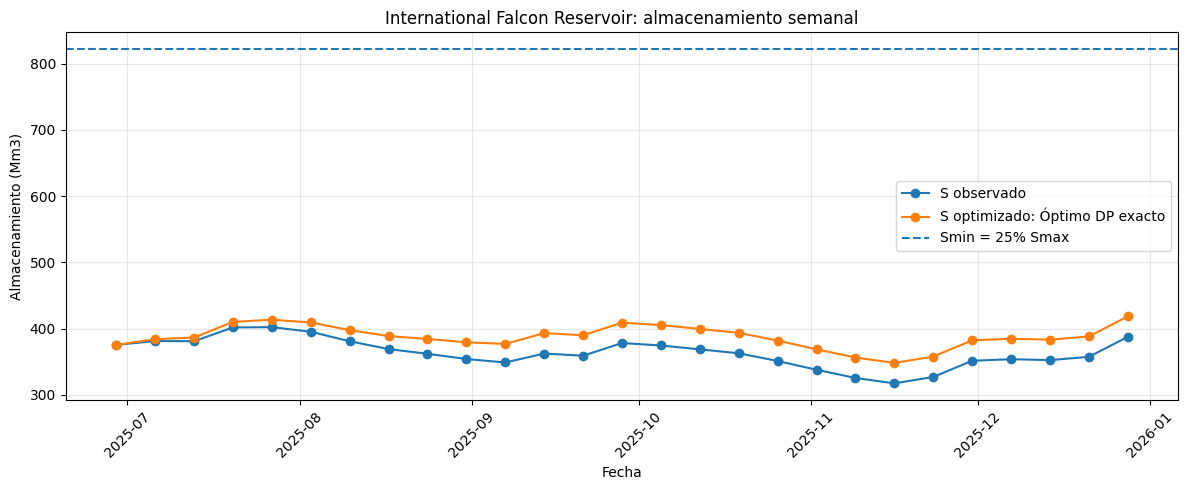

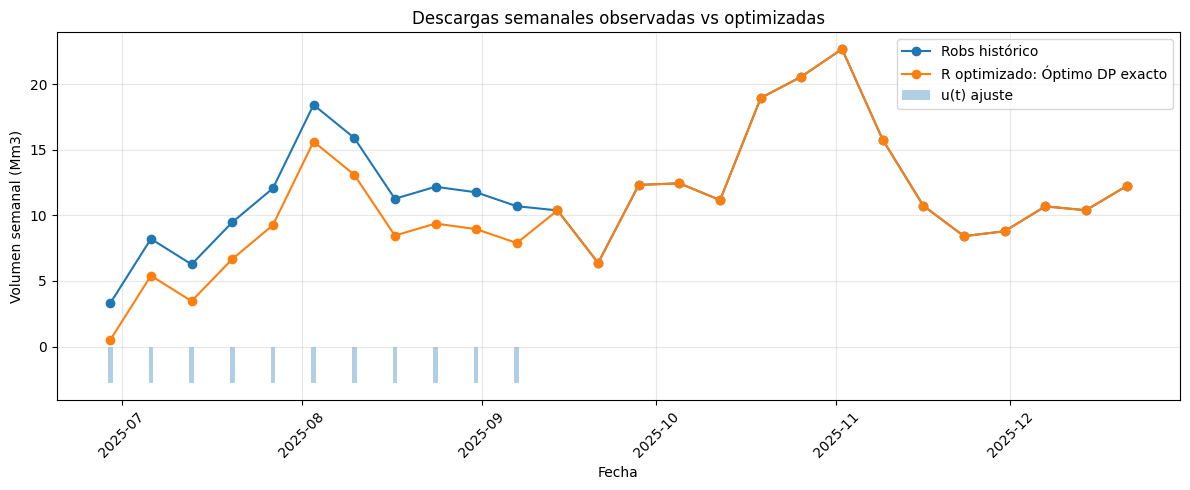

In [ ]:
# =============================
# CELDA 7. Tabla detallada y gráficas
# =============================
best_name = feasible_summary.iloc[0]["política"]
best_u = policies[best_name][0]
best_ev = evals[best_name]

result_df = pd.DataFrame({
    "week_start": dates[:-1],
    "week_end": dates[1:],
    "Robs_m3": Robs,
    "u_opt_m3": best_u,
    "Ropt_m3": best_ev["R"],
    "Sobs_start_m3": Sobs[:-1],
    "Sopt_start_m3": best_ev["Sopt"][:-1],
    "Sobs_end_m3": Sobs[1:],
    "Sopt_end_m3": best_ev["Sopt"][1:],
    "u_units": np.rint(best_u / delta_u).astype(int),
})

out_csv = "falcon_solution_official_T26_L5.csv"
result_df.to_csv(out_csv, index=False)
summary.to_csv("falcon_summary_official_T26_L5.csv", index=False)
print(f"Archivos guardados: {out_csv}, falcon_summary_official_T26_L5.csv")

# Gráfica 1: almacenamiento.
plt.figure(figsize=(12, 5))
plt.plot(dates, Sobs / 1e6, marker="o", label="S observado")
plt.plot(dates, best_ev["Sopt"] / 1e6, marker="o", label=f"S optimizado: {best_name}")
plt.axhline(params.smin_m3 / 1e6, linestyle="--", label="Smin = 25% Smax")
plt.title("International Falcon Reservoir: almacenamiento semanal")
plt.xlabel("Fecha")
plt.ylabel("Almacenamiento (Mm3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("falcon_storage_plot.png", dpi=150)
plt.show()

# Gráfica 2: descargas y ajustes.
plt.figure(figsize=(12, 5))
plt.plot(dates[:-1], Robs / 1e6, marker="o", label="Robs histórico")
plt.plot(dates[:-1], best_ev["R"] / 1e6, marker="o", label=f"R optimizado: {best_name}")
plt.bar(dates[:-1], best_u / 1e6, alpha=0.35, label="u(t) ajuste")
plt.title("Descargas semanales observadas vs optimizadas")
plt.xlabel("Fecha")
plt.ylabel("Volumen semanal (Mm3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("falcon_release_plot.png", dpi=150)
plt.show()

In [ ]:
# =============================
# CELDA 8. Análisis de escalamiento
# =============================
def run_instance(T, L, start_date=None):
    Robs_i, Sobs_i, dates_i, params_i = prepare_weekly_instance(T=T, L=L, start_date=start_date)
    du_i = 0.25 * np.median(Robs_i)
    u_hist_i = historical_policy(T)

    t0 = time.perf_counter()
    u_dp_i, meta_i = dp_optimize(Robs_i, Sobs_i, L, params_i.smin_m3, params_i.smax_m3, params_i.eta, du_i)
    rt_i = time.perf_counter() - t0

    ev_hist_i = evaluate_policy(u_hist_i, Robs_i, Sobs_i, params_i.smin_m3, params_i.smax_m3, params_i.eta, meta_i["weights"])
    ev_dp_i = evaluate_policy(u_dp_i, Robs_i, Sobs_i, params_i.smin_m3, params_i.smax_m3, params_i.eta, meta_i["weights"])

    return {
        "T": T,
        "L": L,
        "Nschedules_L^T": f"{L}^{T}",
        "log10_Nschedules": T * math.log10(L),
        "SRS_hist": ev_hist_i["SRS"],
        "SRS_DP": ev_dp_i["SRS"],
        "ΔSRS_DP_vs_hist": ev_dp_i["SRS"] - ev_hist_i["SRS"],
        "factible_DP": ev_dp_i["feasible"]["all"],
        "runtime_DP_s": rt_i,
        "states_final_DP": meta_i["states_final"],
        "delta_u_Mm3": du_i / 1e6,
        "sum_u_DP_Mm3": ev_dp_i["sum_u"] / 1e6,
    }

scaling_cases = [(12, 3), (26, 5), (52, 5), (52, 7)]
scaling_rows = []
for T_i, L_i in scaling_cases:
    try:
        scaling_rows.append(run_instance(T_i, L_i, start_date=START_DATE))
    except Exception as e:
        scaling_rows.append({"T": T_i, "L": L_i, "error": str(e)})

scaling_df = pd.DataFrame(scaling_rows)
display(scaling_df)
scaling_df.to_csv("falcon_scaling_results.csv", index=False)
print("Archivo guardado: falcon_scaling_results.csv")

print("\nListo. Revisa los CSV y PNG generados en el panel de archivos de Colab.")

,T,L,Nschedules_L^T,log10_Nschedules,SRS_hist,SRS_DP,ΔSRS_DP_vs_hist,factible_DP,runtime_DP_s,states_final_DP,delta_u_Mm3,sum_u_DP_Mm3
0,12,3,3^12,5.725455,-0.296264,-0.296264,0.000000,True,0.002516,27,2.745767,0.000000
1,26,5,5^26,18.173220,-0.311534,-0.290423,0.021111,True,0.051649,115,2.804362,-30.847987
2,52,5,5^52,36.346440,-0.252702,-0.201466,0.051236,True,0.207113,135,3.053171,-67.169771
3,52,7,7^52,43.945098,-0.252702,-0.177643,0.075059,True,0.516693,180,3.053171,-67.169771


Archivo guardado: falcon_scaling_results.csv

Listo. Revisa los CSV y PNG generados en el panel de archivos de Colab.
